In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')

In [3]:
!pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable


# Prediction Models

--- RANDOM FOREST MODEL EVALUATION ---
Overall Accuracy: 0.58

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.62      0.68      1439
           1       0.33      0.49      0.40       561

    accuracy                           0.58      2000
   macro avg       0.55      0.55      0.54      2000
weighted avg       0.64      0.58      0.60      2000



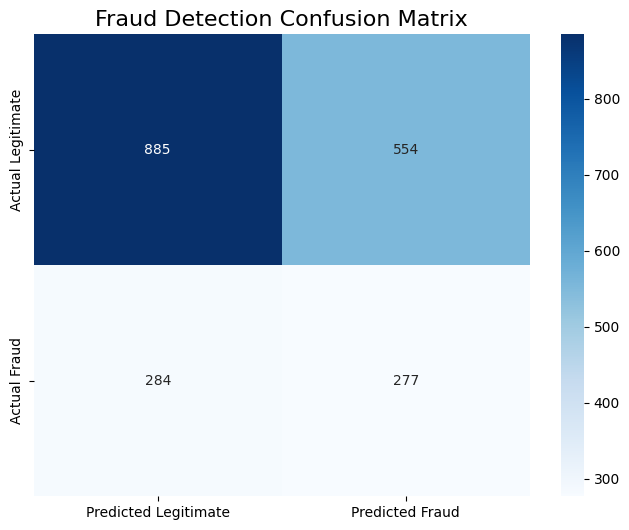

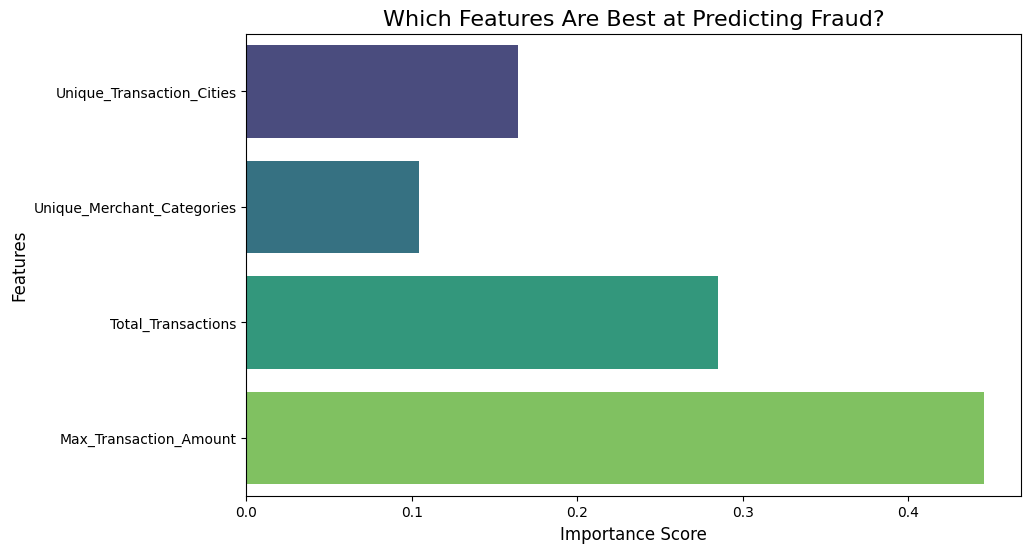

In [3]:
# 1. Import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load the data (assuming it's already loaded, but safe to include)
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Create our Target Variable (1 = Fraudulent, 0 = Legitimate)
df['Is_Fraud'] = (df['Fraud_Transactions'] > 0).astype(int)

# 4. Select the Predictive Features
features = [
    'Unique_Transaction_Cities', 
    'Unique_Merchant_Categories', 
    'Total_Transactions', 
    'Max_Transaction_Amount'
]

X = df[features]
y = df['Is_Fraud']

# 5. Split the Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Build the Random Forest Model 
# n_estimators=100 means it builds 100 different decision trees and averages their guesses
# class_weight='balanced' helps it pay extra attention to the rare fraud cases
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 7. Make Predictions
y_pred = rf_model.predict(X_test)

# 8. PRINT THE TEXT EVALUATION (For Stage 4 of your report)
print("--- RANDOM FOREST MODEL EVALUATION ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 9. VISUALIZATION 1: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'], 
            yticklabels=['Actual Legitimate', 'Actual Fraud'])
plt.title('Fraud Detection Confusion Matrix', fontsize=16)
plt.show()

# 10. VISUALIZATION 2: Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
sns.barplot(x=importances, y=features, palette='viridis', hue=features, legend=False)
plt.title('Which Features Are Best at Predicting Fraud?', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

--- RANDOM FOREST DEFAULT PREDICTION EVALUATION ---
Overall Accuracy: 0.62

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.58      0.67      1320
           1       0.46      0.69      0.55       680

    accuracy                           0.62      2000
   macro avg       0.62      0.64      0.61      2000
weighted avg       0.67      0.62      0.63      2000



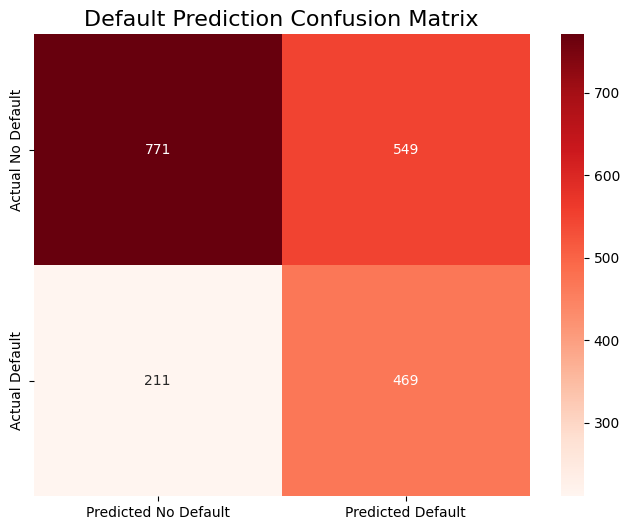

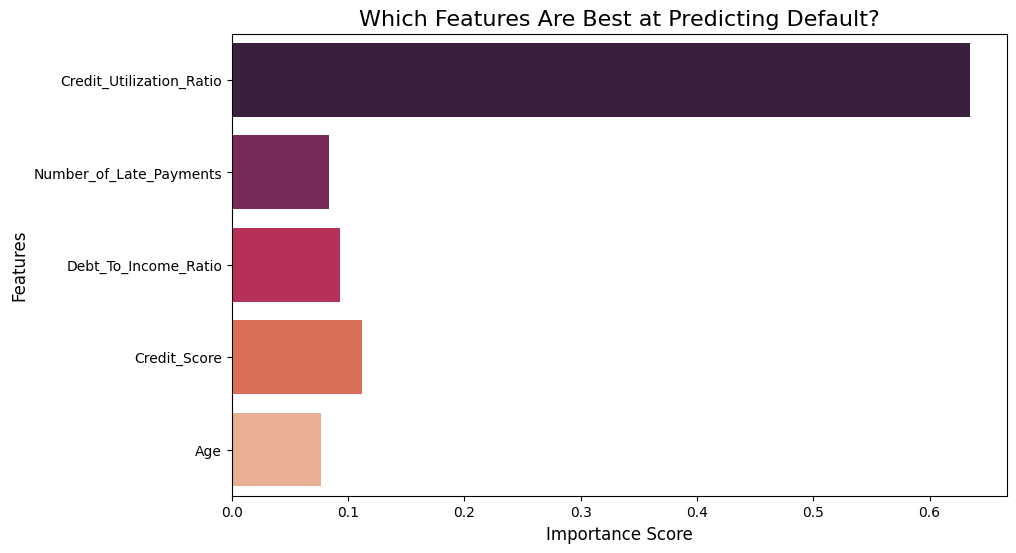

In [4]:
# 1. Import all necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load the data
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Create our Target Variable 
# We don't need to do any math here, because 'Defaulted' is already a 0 or 1 in your dataset!
y = df['Defaulted']

# 4. Select the Predictive Features
# We swapped these out for the features that actually relate to credit risk!
features = [
    'Credit_Utilization_Ratio', 
    'Number_of_Late_Payments', 
    'Debt_To_Income_Ratio', 
    'Credit_Score',
    'Age'
]

X = df[features]

# 5. Split the Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Build the Random Forest Model 
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# 7. Make Predictions
y_pred = rf_model.predict(X_test)

# 8. PRINT THE TEXT EVALUATION (For Stage 4 of your report)
print("--- RANDOM FOREST DEFAULT PREDICTION EVALUATION ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 9. VISUALIZATION 1: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', # Changed to Reds to match the risk theme
            xticklabels=['Predicted No Default', 'Predicted Default'], 
            yticklabels=['Actual No Default', 'Actual Default'])
plt.title('Default Prediction Confusion Matrix', fontsize=16)
plt.show()

# 10. VISUALIZATION 2: Feature Importance Bar Chart
plt.figure(figsize=(10, 6))
importances = rf_model.feature_importances_
ax = sns.barplot(x=importances, y=features, palette='rocket', hue=features)

# Clean up the legend if one accidentally appears
if ax.get_legend():
    ax.get_legend().remove()

plt.title('Which Features Are Best at Predicting Default?', fontsize=16)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

[LightGBM] [Info] Number of positive: 2267, number of negative: 5733
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000258 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 310
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 4
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

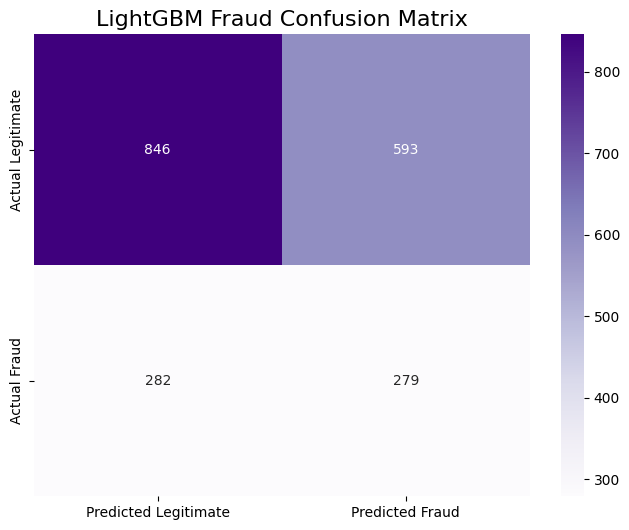

<Figure size 1000x600 with 0 Axes>

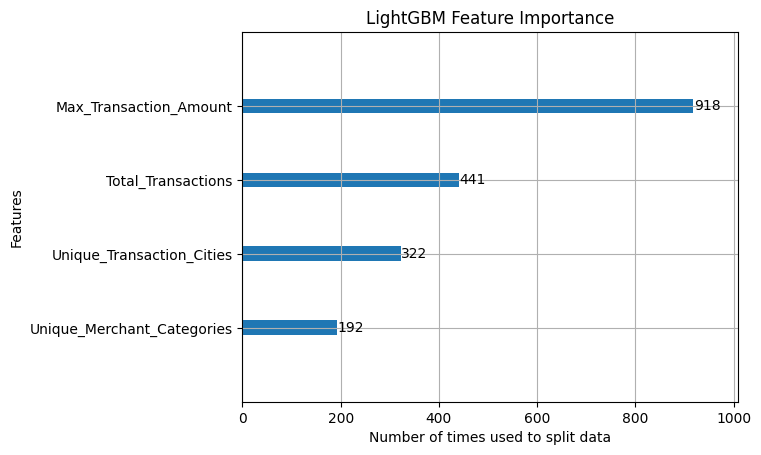

In [5]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import lightgbm as lgb

# 2. Load the dataset
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Create the Binary Target Variable (1 = Fraud, 0 = Legitimate)
df['Is_Fraud'] = (df['Fraud_Transactions'] > 0).astype(int)

# 4. Select the Predictive Features
features = [
    'Unique_Transaction_Cities', 
    'Unique_Merchant_Categories', 
    'Total_Transactions', 
    'Max_Transaction_Amount'
]

X = df[features]
y = df['Is_Fraud']

# 5. Split the Data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Build and Train the LightGBM Model
# class_weight='balanced' ensures it pays attention to the minority fraud cases
lgb_model = lgb.LGBMClassifier(
    n_estimators=100, 
    learning_rate=0.05, 
    max_depth=5, 
    class_weight='balanced', 
    random_state=42
)

lgb_model.fit(X_train, y_train)

# 7. Make Predictions
y_pred = lgb_model.predict(X_test)

# 8. TEXT EVALUATION
print("--- LIGHTGBM FRAUD PREDICTION EVALUATION ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred):.2f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

# 9. VISUALIZATION 1: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', # Using Purples for a fresh look!
            xticklabels=['Predicted Legitimate', 'Predicted Fraud'], 
            yticklabels=['Actual Legitimate', 'Actual Fraud'])
plt.title('LightGBM Fraud Confusion Matrix', fontsize=16)
plt.show()

# 10. VISUALIZATION 2: LightGBM Built-in Feature Importance
plt.figure(figsize=(10, 6))
# LightGBM has its own plotting function which looks very professional!
lgb.plot_importance(lgb_model, importance_type='split', max_num_features=10, 
                    title='LightGBM Feature Importance', xlabel='Number of times used to split data')
plt.show()

--- LOGISTIC REGRESSION: DEFAULT PREDICTION ---
Overall Accuracy: 0.63

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.62      0.68      1320
           1       0.46      0.65      0.54       680

    accuracy                           0.63      2000
   macro avg       0.62      0.63      0.61      2000
weighted avg       0.67      0.63      0.64      2000



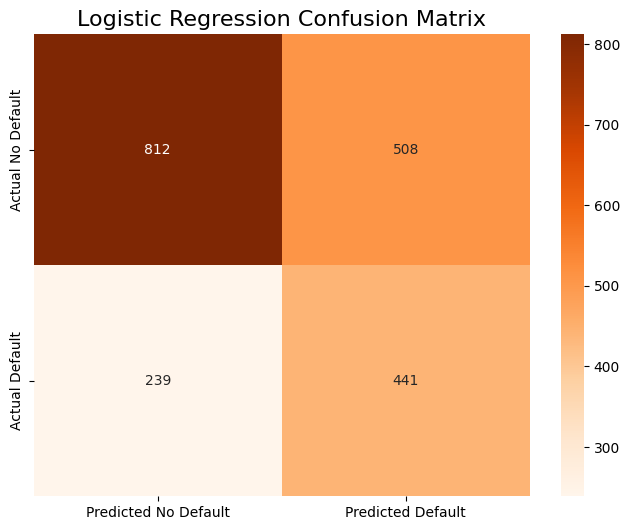

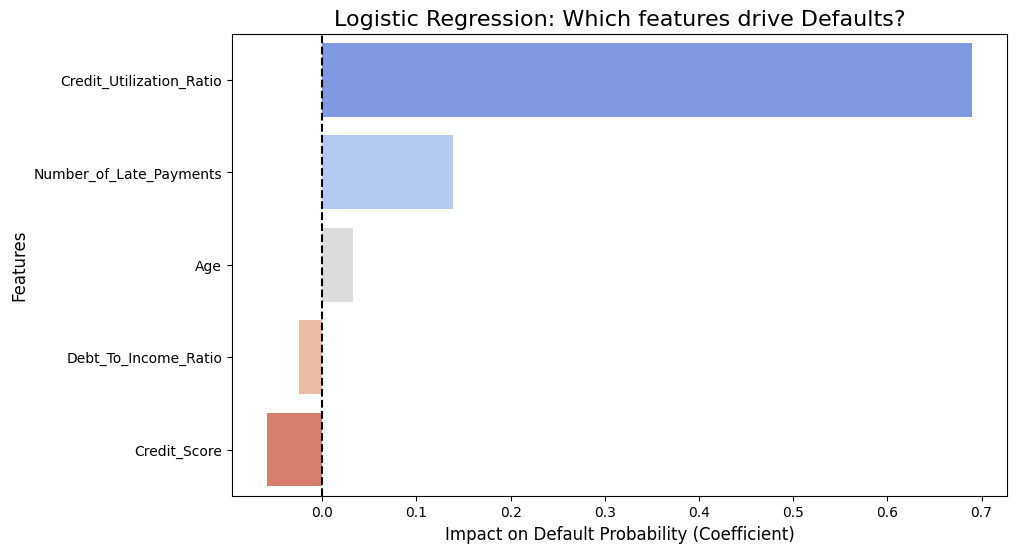

In [6]:
# 1. Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 2. Load the data
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. Create Target Variable and Features
y = df['Defaulted']

features = [
    'Credit_Utilization_Ratio', 
    'Number_of_Late_Payments', 
    'Debt_To_Income_Ratio', 
    'Credit_Score',
    'Age'
]

X = df[features]

# 4. Split the Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. SCALE THE DATA (Crucial for Logistic Regression!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test) # We only transform the test set so the model can't "cheat" and see it early

# 6. Build the Logistic Regression Model
# class_weight='balanced' ensures it pays equal attention to the defaults
log_model = LogisticRegression(class_weight='balanced', random_state=42)
log_model.fit(X_train_scaled, y_train)

# 7. Make Predictions
y_pred_log = log_model.predict(X_test_scaled)

# 8. TEXT EVALUATION
print("--- LOGISTIC REGRESSION: DEFAULT PREDICTION ---")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred_log):.2f}\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_log))

# 9. VISUALIZATION 1: Confusion Matrix
plt.figure(figsize=(8, 6))
cm_log = confusion_matrix(y_test, y_pred_log)
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Predicted No Default', 'Predicted Default'], 
            yticklabels=['Actual No Default', 'Actual Default'])
plt.title('Logistic Regression Confusion Matrix', fontsize=16)
plt.show()

# 10. VISUALIZATION 2: Feature Importance (Coefficients)
# Logistic Regression doesn't have "feature importances", it has "coefficients"
coefficients = pd.DataFrame({
    'Feature': features, 
    'Coefficient': log_model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=coefficients, x='Coefficient', y='Feature', palette='coolwarm', hue='Feature', legend=False)
plt.title('Logistic Regression: Which features drive Defaults?', fontsize=16)
plt.xlabel('Impact on Default Probability (Coefficient)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Adds a line at zero
plt.show()

# Association Rule Mining

In [4]:
# 1. Import Libraries
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

# 2. Load Data
df = pd.read_csv('Credit_Card_Dataset.csv')

# 3. DISCRETIZATION: Convert numbers into True/False "Market Basket" items
basket = pd.DataFrame()

# We define what "High" means for each category to create our True/False columns
basket['High_Utilization'] = df['Credit_Utilization_Ratio'] >= 0.70
basket['Has_Late_Payments'] = df['Number_of_Late_Payments'] >= 1
basket['High_Debt_to_Income'] = df['Debt_To_Income_Ratio'] >= 0.50
basket['Low_Credit_Score'] = df['Credit_Score'] <= 650
basket['Has_Defaulted'] = df['Defaulted'] == 1

# Ensure everything is strictly a Boolean (True/False) format for the algorithm
basket = basket.astype(bool)

# 4. RUN APRIORI ALGORITHM
# min_support=0.1 means a combination must appear in at least 10% of customers to be considered a "rule"
frequent_itemsets = apriori(basket, min_support=0.1, use_colnames=True)

# 5. GENERATE THE RULES
# We use 'lift' to measure how strongly the items are connected. 
# A lift > 1 means the items appear together more often than random chance.
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

# 6. FILTER THE RULES FOR OUR BUSINESS PROBLEM
# We only care about rules where the result (the "consequent") is 'Has_Defaulted'
default_rules = rules[rules['consequents'] == frozenset({'Has_Defaulted'})]

# 7. Sort the rules by "Confidence" (how often the rule is right)
default_rules = default_rules.sort_values(by=['confidence', 'lift'], ascending=[False, False])

# 8. Print the top 5 most powerful risk rules!
print("--- Top Association Rules for Predicting Defaults ---")
for index, row in default_rules.head(5).iterrows():
    # Formatting it to read like plain English
    antecedents = list(row['antecedents'])
    confidence = row['confidence'] * 100
    lift = row['lift']
    print(f"IF a customer has {antecedents}, THEN they have a {confidence:.1f}% chance of Defaulting. (Lift: {lift:.2f})")

--- Top Association Rules for Predicting Defaults ---
IF a customer has ['High_Utilization'], THEN they have a 52.0% chance of Defaulting. (Lift: 1.51)
IF a customer has ['Has_Late_Payments', 'High_Utilization'], THEN they have a 51.6% chance of Defaulting. (Lift: 1.50)
